In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train_dir='/content/drive/MyDrive/MRI/Training'
test_dir='/content/drive/MyDrive/MRI/Testing'

train_paths=[]
train_label=[]

for label in os.listdir(train_dir):
  print(label)
  for img in os.listdir(os.path.join(train_dir,label)):
    train_paths.append(os.path.join(train_dir,label,img))
    train_label.append(label)

train_paths,train_label=shuffle(train_paths,train_label)

test_paths=[]
test_label=[]

for label in os.listdir(test_dir):
  print(label)
  for img in os.listdir(os.path.join(test_dir,label)):
    test_paths.append(os.path.join(test_dir,label,img))
    test_label.append(label)

train_paths,train_label=shuffle(train_paths,train_label)



notumor
pituitary
glioma
meningioma
meningioma
notumor
pituitary
glioma


In [ ]:
os.listdir(train_dir)

['notumor', 'pituitary', 'glioma', 'meningioma']

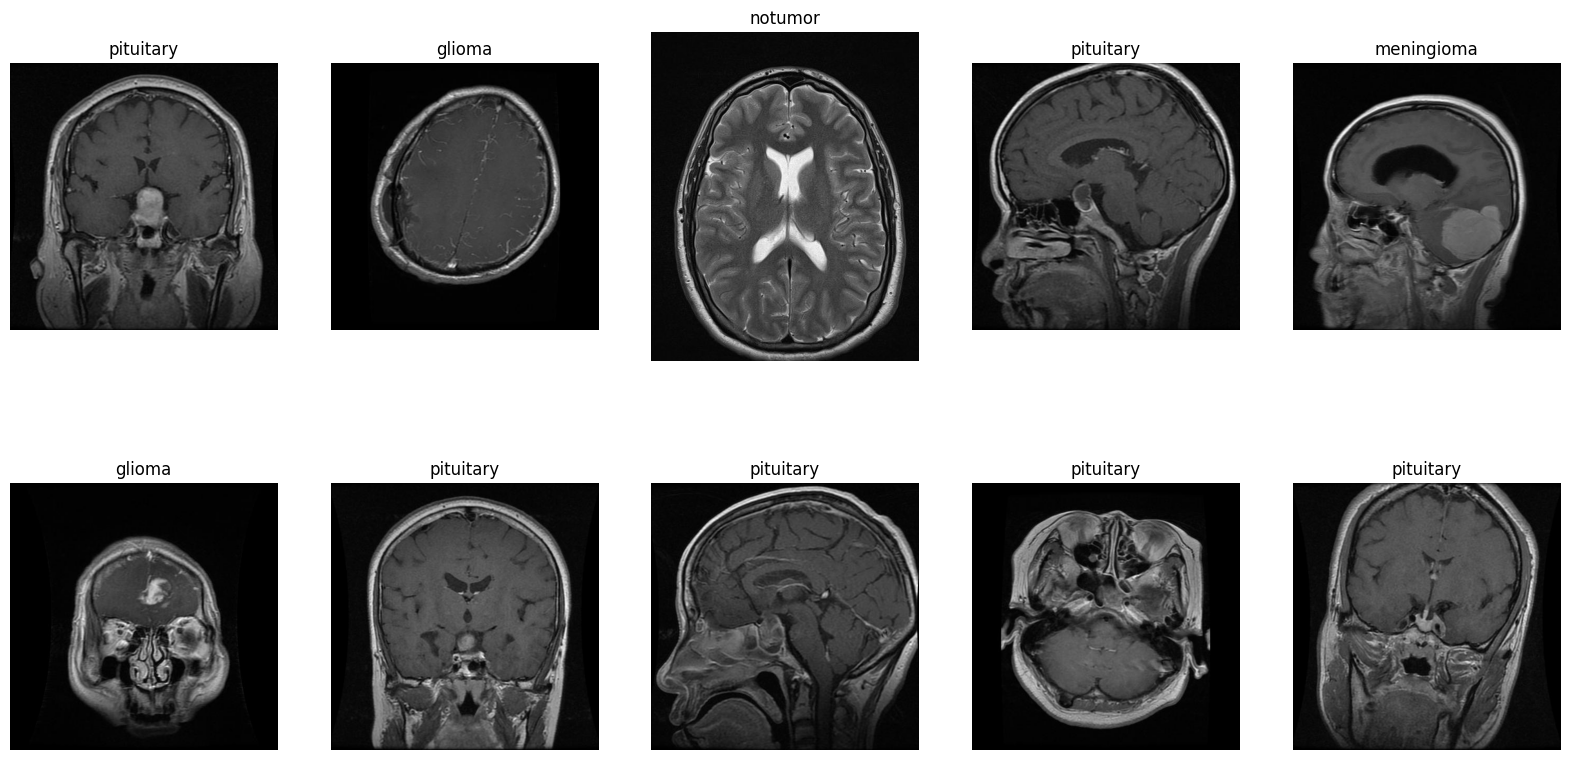

In [ ]:
random_indices=random.sample(range(0,len(train_paths)),10)
fig,axes =plt.subplots(2,5,figsize=(20,10))
axes=axes.ravel()

for i,idx in enumerate(random_indices):
  axes[i].imshow(cv2.imread(train_paths[idx]))
  axes[i].set_title(train_label[idx])
  axes[i].axis('off')
plt.show()


image preprocessing


In [ ]:
def augment_image(image):
  image=Image.fromarray(np.uint8(image))
  image=ImageEnhance.Brightness(image).enhance(random.uniform(0.8,1.2))
  image=ImageEnhance.Contrast(image).enhance(random.uniform(0.8,1.2))
  image=np.array(image)/255.0
  return image


def open_images(paths):
  images=[]
  for path in paths:
    img=cv2.imread(path)
    if img is not None:

      img = cv2.resize(img, (image_size, image_size))
      image=augment_image(img)
      images.append(image)
  return np.array(images)

def encode_label(labels):
  unique_labels=np.unique(labels)
  unique_labels=os.listdir(train_dir)
  encoded=[unique_labels.index(label) for label in labels]
  return np.array(encoded)


def datagen(paths,labels,batch_size=12):
  for i in range(0,len(paths),batch_size):
      batches_paths=paths[i:i+batch_size]
      batch_images=open_images(batches_paths)
      batch_labels=encode_label(labels[i:i+batch_size])
      yield batch_images,batch_labels

In [ ]:
from tensorflow.keras.applications import VGG16

image_size=128
base_model=VGG16(input_shape=(image_size,image_size,3),include_top=False,weights='imagenet')




58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/model.h5")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/content/drive/MyDrive/model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
import os
print(os.listdir("/content"))

['.config', 'drive', 'sample_data']


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Re-instantiate ModelCheckpoint and EarlyStopping callbacks
model_checkpoint_callback = ModelCheckpoint(
    filepath="/content/drive/MyDrive/model.keras",
    save_best_only=False, # Save model after each epoch
    save_freq='epoch',
    verbose=1
)

# early_stop was already defined in URhdYHFSRyZU
callbacks_list = [model_checkpoint_callback, early_stop]

# Resume training
history = model.fit(
    datagen(train_paths, train_label, batch_size=batch_size),
    steps_per_epoch=steps,
    epochs=epochs,
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/5
 23/280 ━━━━━━━━━━━━━━━━━━━━ 36:02 8s/step - loss: 1.1205 - sparse_categorical_accuracy: 0.5244

KeyboardInterrupt: 

In [ ]:
from keras.src.backend.config import set_max_steps_per_epoch
from tensorflow.keras.layers import Input
from tensorflow.keras.optimizers import Adam

#freeze all layers
for layer in base_model.layers:
  layer.trainable=False
#set only last few layers
for layer in base_model.layers[-4:]:
  layer.trainable=True

#build model
model=Sequential()
model.add(Input(shape=(image_size,image_size,3)))
model.add(base_model)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(4,activation='softmax')) #
model.compile(optimizer=Adam(learning_rate=0.0001),loss='sparse_categorical_crossentropy',metrics=['sparse_categorical_accuracy'])

batch_size=20
steps=int(len(train_paths)/batch_size)
epochs=5

#train
# Modified model.fit call to pass steps_per_epoch and epochs directly to fit method
ModelCheckpoint(
    "/content/drive/MyDrive/model.keras",
    save_best_only=False,
    save_freq='epoch'
)
history=model.fit(datagen(train_paths,train_label,batch_size=batch_size),
                  steps_per_epoch=steps,
                  epochs=epochs)

In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D
from sklearn.metrics import accuracy_score
from sklearn.utils import shuffle


In [ ]:
import ipywidgets as widgets
import io
from PIL import Image, ImageEnhance
import tqdm
from sklearn.model_selection import train_test_split
import cv2
import shutil
import numpy as np
import tensorflow as tf
import os
import random
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',   # what to track
    patience=3,           # epochs to wait before stopping
    restore_best_weights=True
)

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,auc
from sklearn.preprocessing import label_binarize

test_images=open_images(test_paths)
test_labels=encode_label(test_label)

test_predictions=model.predict(test_images)
print("classification report:")
print(classification_report(test_labels,np.argmax(test_predictions,axis=1)))


In [ ]:
conf_matrix=confusion_matrix(test_labels,np.argmax(test_predictions,axis=1))
print(conf_matrix)

plt.figure(figsize=(8,6))


In [ ]:
model.save('model.h5')

In [ ]:
#load trained model
from tensorflow.keras.models import load_model
model=load_model('model.h5')

In [ ]:
from keras.preprocessing.image import load_img,img_to_array

In [ ]:
def detect_and_display(image_path,model):
  try:
    img=load_img(image_path,target_size=(128,128))
    img_array=img_to_array(img)
    img=np.expand_dims(img,axis=0)

    predictions=model.predict(img_array)
    predicted_class_index=np.argmax(predictions)
    class_labels=['glioma_tumor','meningioma_tumor','no_tumor','pituitary_tumor']
    confidence_score=max(predictions[0][predicted_class_index])

    predicted_class=class_labels[predicted_class_index]
    print(f"Predicted Class: {predicted_class}")


    if class_labels[predicted_class_index]=='notumor':
      print("No Tumor Detected")

    else:
      print(f"Tumor Detected:{class_labels[predicted_class_index]}")
      print(f"Confidence Score:{confidence_score*100}")

    plt.imshow(img)
    plt.axis('off')
    plt.show()
  except Exception as e:
    print("error processing the image",str(e))










In [ ]:
image_path='/content/drive/MyDrive/MRI/Testing/glioma_tumor/gg (1).jpg'
detect_and_display(image_path,model)